# Signal to distance calibration

In [94]:
from PIL import Image, ImageDraw
import os
import csv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.ndimage import convolve

In [95]:
def sum_around_brightest(path, radius=30):
    img = np.array(Image.open(path).convert("L"), dtype=np.float32)

    # Sum of 5 consecutive pixels in each row → find the peak window center
    kernel = np.ones((5, 5))
    smoothed = convolve(img, kernel, mode='reflect')
    row, col = np.unravel_index(np.argmax(smoothed), img.shape)

    r0, r1 = max(row - radius, 0), min(row + radius + 1, img.shape[0])
    c0, c1 = max(col - radius, 0), min(col + radius + 1, img.shape[1])

    return img[r0:r1, c0:c1].sum(), (row, col)



In [96]:
folders = ["1522705scan_images","14330705_cleaned","14330705scan_images","20260511_131017_scan_images","20260511_131558_scan_images","20260511_161856_scan_images","20260512_082718_scan_images","20260512_083248_scan_images","20260512_083720_scan_images","20260512_111543_scan_images","20260512_144033_scan_images","20260512_144420_scan_images","20260512_144910_scan_images","20260512_145302_scan_images","20260513_085941_scan_images"]

colours =[
    [0.4, 0.4, 0.4],     # Folder 1 (Gray family)
    [0.5, 0.5, 0.5],     # Folder 2 (Gray family)
    [0.6, 0.6, 0.6],     # Folder 3 (Gray family)
    [0.1, 0.2, 0.6],     # Folder 4 (Blue family - Day 20260511)
    [0.2, 0.4, 0.8],     # Folder 5 (Blue family - Day 20260511)
    [0.4, 0.6, 0.9],     # Folder 6 (Blue family - Day 20260511)
    [0.6, 0.0, 0.0],     # Folder 7 (Red family - Day 20260512)
    [0.7, 0.1, 0.1],     # Folder 8 (Red family - Day 20260512)
    [0.8, 0.2, 0.2],     # Folder 9 (Red family - Day 20260512)
    [0.9, 0.3, 0.3],     # Folder 10 (Red family - Day 20260512)
    [0.95, 0.4, 0.4],    # Folder 11 (Red family - Day 20260512)
    [0.5, 0.1, 0.1],     # Folder 12 (Red family - Day 20260512)
    [0.75, 0.25, 0.25],  # Folder 13 (Red family - Day 20260512)
    [0.85, 0.35, 0.35],  # Folder 14 (Red family - Day 20260512)
    [0.1, 0.5, 0.1]      # Folder 15 (Green family - Day 20260513)
]


In [97]:
STEP_MM = 0.5                  # move in 0.5 mm increments
STEPS_PER_MM = int(1e-3/(0.5e-9*8))
steps = STEPS_PER_MM * STEP_MM * np.linspace(0,20,21) # steps taken by motor

all_signals = []
radii = np.linspace(40,60,5)
# Save all signals
for folder_path in folders:
    file_paths = sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(".png")
    ])
    signal = [sum_around_brightest(p)[0] for p in file_paths]
    all_signals.append(signal)

all_signals = np.array(all_signals)

(15, 21)


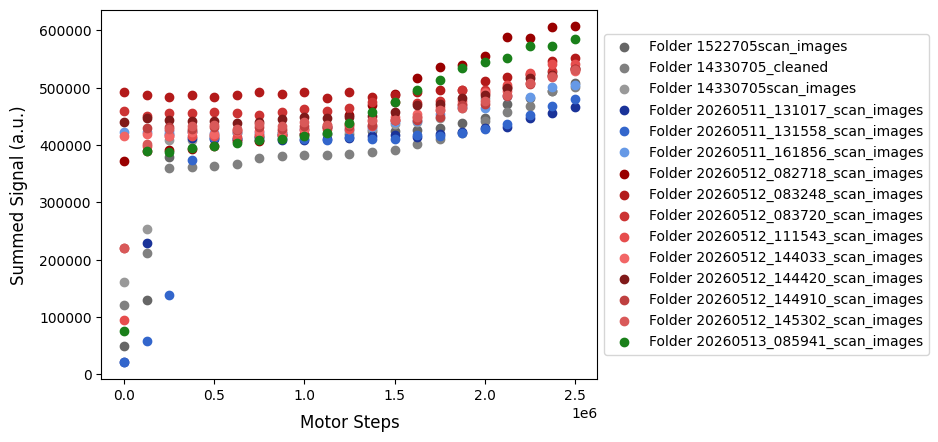

In [98]:
print(np.shape(all_signals))
for i,(s,c) in enumerate(zip(all_signals,colours)):
    plt.scatter(steps, s, label = f"Folder {folders[i]}", color = c)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xlabel("Motor Steps", fontsize=12, labelpad=8)
plt.ylabel("Summed Signal (a.u.)", fontsize=12, labelpad=8)
plt.savefig("rawdata.pdf", bbox_inches='tight')

(15, 21)


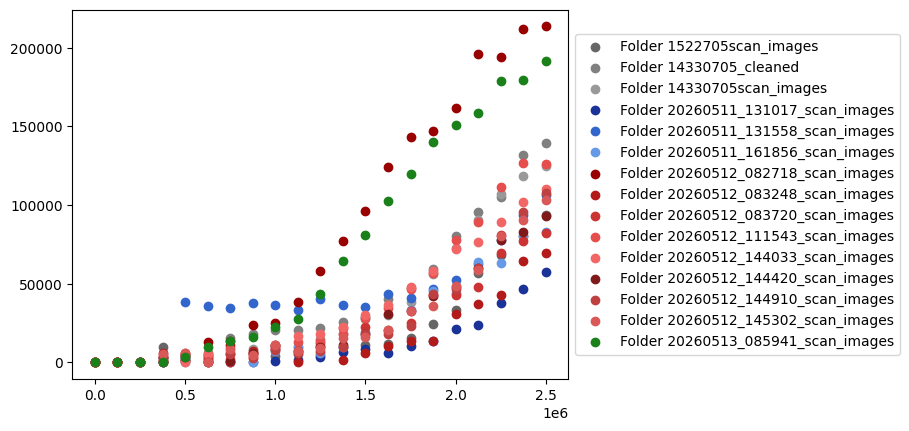

In [99]:

cleaned_signals = all_signals.copy()
reference_point = np.min(cleaned_signals[:,3:], axis=1)
cleaned_signals = cleaned_signals - reference_point[:, np.newaxis]
cleaned_signals[:, :3] = 0
print(np.shape(cleaned_signals))
for i,(s,c) in enumerate(zip(cleaned_signals,colours)):
    plt.scatter(steps, s, label = f"Folder {folders[i]}", color = c)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

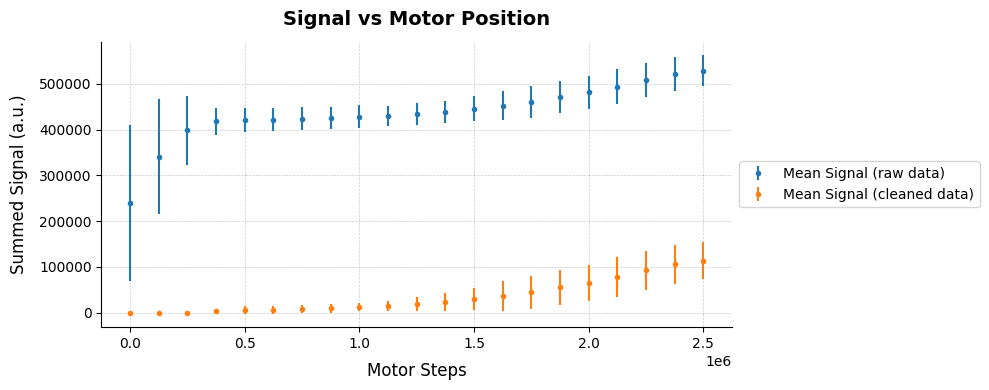

In [100]:


mean_signal = np.mean(all_signals, axis=0)
std_signal = np.std(all_signals, axis=0)

mean_signal_cleaned = np.mean(cleaned_signals, axis=0)
std_signal_cleaned = np.std(cleaned_signals, axis=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 4))

ax.errorbar(steps, mean_signal, yerr=std_signal, fmt=".", label="Mean Signal (raw data)")
ax.errorbar(steps, mean_signal_cleaned, yerr=std_signal_cleaned, fmt=".", label="Mean Signal (cleaned data)")
ax.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.4)
ax.set_axisbelow(True)

ax.set_xlabel("Motor Steps", fontsize=12, labelpad=8)
ax.set_ylabel("Summed Signal (a.u.)", fontsize=12, labelpad=8)
ax.set_title("Signal vs Motor Position", fontsize=14, fontweight="bold", pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(labelsize=10)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

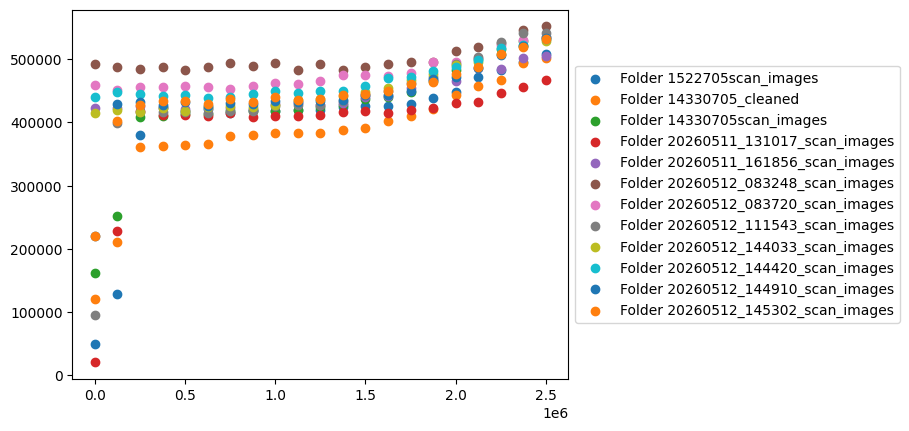

In [101]:
folders = ["1522705scan_images","14330705_cleaned","14330705scan_images","20260511_131017_scan_images","20260511_161856_scan_images","20260512_083248_scan_images","20260512_083720_scan_images","20260512_111543_scan_images","20260512_144033_scan_images","20260512_144420_scan_images","20260512_144910_scan_images","20260512_145302_scan_images"]

all_signals = []
# Save all signals
for folder_path in folders:
    file_paths = sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(".png")
    ])
    signal = [sum_around_brightest(p)[0] for p in file_paths]
    all_signals.append(signal)

all_signals = np.array(all_signals)

for i,s in enumerate(all_signals):
    plt.scatter(steps, s, label = f"Folder {folders[i]}")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

(12, 21)


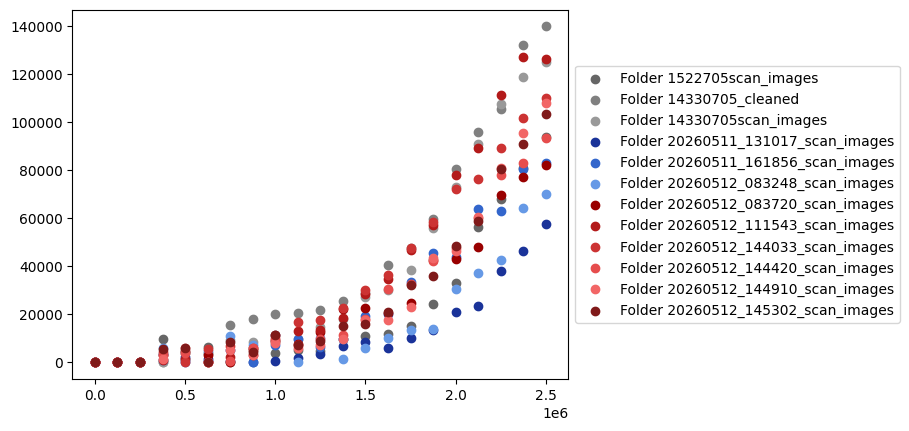

In [102]:
cleaned_signals = all_signals.copy()
reference_point = np.min(cleaned_signals[:,3:], axis=1)
cleaned_signals = cleaned_signals - reference_point[:, np.newaxis]
cleaned_signals[:, :3] = 0
print(np.shape(cleaned_signals))
for i,(s,c) in enumerate(zip(cleaned_signals,colours)):
    plt.scatter(steps, s, label = f"Folder {folders[i]}", color = c)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

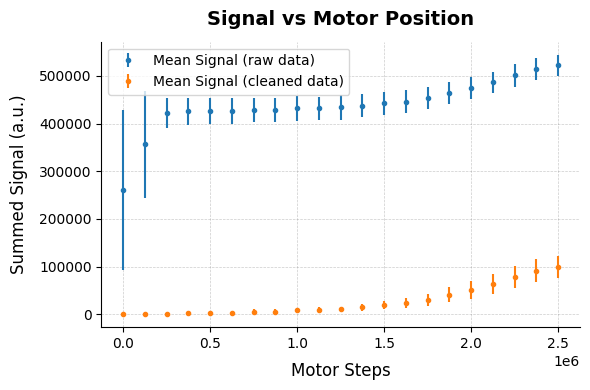

In [103]:
mean_signal = np.mean(all_signals, axis=0)
std_signal = np.std(all_signals, axis=0)

mean_signal_cleaned = np.mean(cleaned_signals, axis=0)
std_signal_cleaned = np.std(cleaned_signals, axis=0)

cutoff_idx = 9


# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(steps, mean_signal, yerr=std_signal, fmt=".", label="Mean Signal (raw data)")
ax.errorbar(steps, mean_signal_cleaned, yerr=std_signal_cleaned, fmt=".", label="Mean Signal (cleaned data)")
ax.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.4)
ax.set_axisbelow(True)

ax.set_xlabel("Motor Steps", fontsize=12, labelpad=8)
ax.set_ylabel("Summed Signal (a.u.)", fontsize=12, labelpad=8)
ax.set_title("Signal vs Motor Position", fontsize=14, fontweight="bold", pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(labelsize=10)
plt.legend()
plt.tight_layout()
plt.show()

Slope: 13910.438669718787 +/- 2191.503591074688
Intercept: -59134.71000429352 +/- 12659.546850730136
Best fit model:-59134.710 + 13910.438670d 


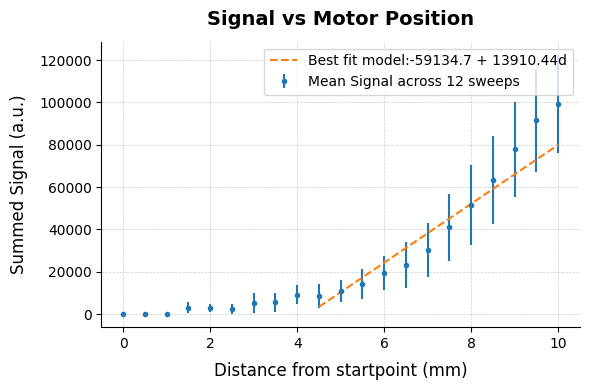

In [104]:
steps = STEP_MM * np.linspace(0,20,21)
mean_signal = np.mean(all_signals, axis=0)
std_signal = np.std(all_signals, axis=0)

mean_signal_cleaned = np.mean(cleaned_signals, axis=0)
std_signal_cleaned = np.std(cleaned_signals, axis=0)

cutoff_idx = 9

def linear_model(x, slope, intercept):
    return slope * x + intercept

x_data = steps[cutoff_idx:]
y_data = mean_signal_cleaned[cutoff_idx:]
y_error = std_signal_cleaned[cutoff_idx:]

popt, pcov = curve_fit(linear_model, x_data, y_data, sigma=y_error, absolute_sigma=True)

slope, intercept = popt
slope_error = np.sqrt(pcov[0, 0])
intercept_error = np.sqrt(pcov[1, 1])

print(f"Slope: {slope} +/- {slope_error}")
print(f"Intercept: {intercept} +/- {intercept_error}")
print(f"Best fit model:{intercept:.3f} + {slope:3f}d ")
x_grid = np.linspace(min(x_data), max(x_data), 100)
y_grid = linear_model(x_grid, slope, intercept)
# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(steps, mean_signal_cleaned, yerr=std_signal_cleaned, fmt=".", label=f"Mean Signal across {len(folders)} sweeps")
ax.plot(x_grid,y_grid, label=f"Best fit model:{intercept:.1f} + {slope:.2f}d", linestyle="--")

ax.grid(True, linestyle="--", linewidth=0.5, color="grey", alpha=0.4)
ax.set_axisbelow(True)

ax.set_xlabel("Distance from startpoint (mm)", fontsize=12, labelpad=8)
ax.set_ylabel("Summed Signal (a.u.)", fontsize=12, labelpad=8)
ax.set_title("Signal vs Motor Position", fontsize=14, fontweight="bold", pad=12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.8)
ax.spines["bottom"].set_linewidth(0.8)

ax.tick_params(labelsize=10)
plt.legend()
plt.tight_layout()
plt.savefig("calibration.pdf")
plt.show()

In [105]:
STEP_MM = 0.5                  # move in 0.5 mm increments
STEPS_PER_MM = int(1e-3/(0.5e-9*8))
steps = STEPS_PER_MM * STEP_MM * np.linspace(0,20,21) # steps taken by motor

signals_vs_radii = []
radii = np.linspace(40,60,5)
# Save all signals
for r in radii:
    all_signals = []
    for folder_path in folders:
        file_paths = sorted([
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(".png")
        ])
        signal = [sum_around_brightest(p)[0] for p in file_paths]
        all_signals.append(signal)
    signals_vs_radii.append(all_signals)

all_signals = np.array(all_signals)
signals_vs_radii = np.array(signals_vs_radii)